# Data preprocessing

Download the raw data and prepare it for the data mining in the other notebooks

In [ ]:
# download raw data to data/copenhagen/ if missing
!bash ../scripts/download.sh

## Setup

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, "../src")
import pandas as pd
import preprocess as pp

## The data

The Copenhagen Networks Study followed more than 700 first-year students at the Technical University of Denmark for four weeks. Four files, one per kind of contact:

- **Bluetooth proximity** (`bt_symmetric.csv`): every five minutes each phone searched for other phones nearby and recorded which ones it found and how strong the signal was.
- **Calls** (`calls.csv`) and **text messages** (`sms.csv`): one row per call or message, with sender, receiver and time. Calls also have a length in seconds.
- **Facebook friendships** (`fb_friends.csv`): "a static snapshot of the friendship network among the participants at the end of the observation period". It says who was a friend at the end, not when the friendship started.

Students are numbers, not names, and times are seconds counted from the start of the study. There are no calendar dates.

`genders.csv` is not used, since none of our question is about gender. 

Source: Sapiezynski, P., Stopczynski, A., Lassen, D. D. and Lehmann, S. (2019). Interaction data from the Copenhagen Networks Study. *Scientific Data* 6, 315. https://doi.org/10.1038/s41597-019-0325-x


In [ ]:
bt = pp.load_bt()
fb = pp.load_fb()
calls = pp.load_calls()
sms = pp.load_sms()
frames = {"bluetooth": bt, "facebook": fb, "calls": calls, "sms": sms}

# inspect dataframes (rows & memory usage)
for name, df in frames.items():
    print(f"{name}: {len(df):,} rows, {df.memory_usage().sum() / 1e6:.1f} MB")

bluetooth: 5,474,289 rows, 49.3 MB
facebook: 6,429 rows, 0.0 MB
calls: 3,600 rows, 0.0 MB
sms: 24,333 rows, 0.2 MB


In [9]:
bt.head()

,timestamp,user_a,user_b,rssi
0,0,0,-1,0
1,0,1,-1,0
2,0,2,-1,0
3,0,3,-2,-88
4,0,5,-1,0


## Exploration

The first checks are for missing values, duplicates, and rows that pair a student with themselves.

Findings: 11 Facebook rows where a student is their own friend, and 21 text messages that appear twice.


The phones scanned every five minutes, and each scan is rounded to a five-minute bin, so every timestamp is a multiple of 300 seconds. All 8,064 bins of the 28 days are there, and 434 to 577 students are in each of them.

Every pair is stored once per bin, with the larger student number first. To find everyone near one student, both columns have to be searched.


In [10]:
# real pairs of participants
real = bt[bt.user_b >= 0]

checks = pd.DataFrame(
    {
        "nulls": [df.isna().sum().sum() for df in frames.values()],
        "duplicates": [df.duplicated().sum() for df in frames.values()],
        "self-pairs": [
            (real.user_a == real.user_b).sum(),
            (fb.user_a == fb.user_b).sum(),
            (calls.caller == calls.callee).sum(),
            (sms.sender == sms.recipient).sum()
        ]
    },
    index=frames.keys()
)
checks

,nulls,duplicates,self-pairs
bluetooth,0,0,0
facebook,0,0,11
calls,0,0,0
sms,0,21,0


In [13]:
per_bin = pp.presence(bt).groupby("timestamp").size()

print("timestamps on the 300 s grid:", (bt.timestamp % pp.BIN == 0).all())
print("bins present:", bt.timestamp.nunique(), "of", pp.N_BINS)
print("students reporting per bin:", per_bin.min(), "to", per_bin.max())
print("real pairs stored with user_a > user_b:", (real.user_a > real.user_b).all())
print("same pair twice in one bin:", real.duplicated(["timestamp", "user_a", "user_b"]).sum())

timestamps on the 300 s grid: True
bins present: 8064 of 8064
students reporting per bin: 434 to 577
real pairs stored with user_a > user_b: True
same pair twice in one bin: 0


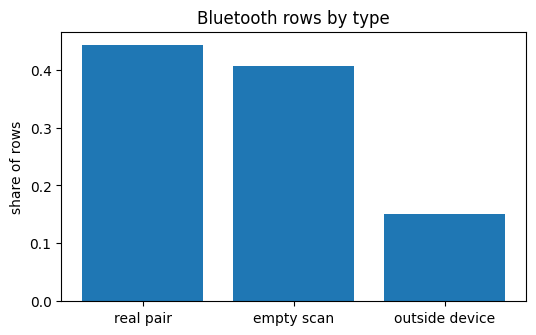

In [14]:
fig = pp.plot_row_types(bt)

A row does not always report two students. The `user_b` column holds a student number, or a marker: -1 for empty scans and -2 for devices ourside the study. The markers are 56% of all rows.


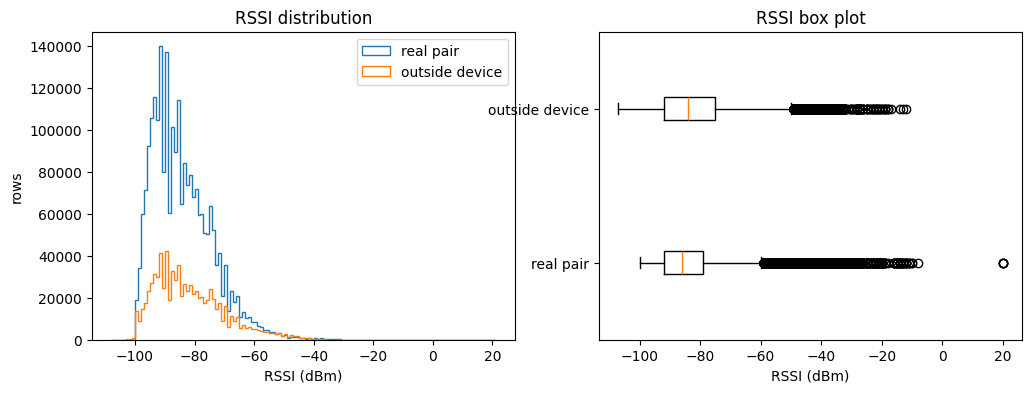

In [15]:
fig = pp.plot_rssi(bt)

In [16]:
real.rssi.quantile([0.25, 0.5, 0.75])

0.25   -92.0
0.50   -86.0
0.75   -79.0
Name: rssi, dtype: float64

RSSI (Received Signal Strength Indicator) is the strength of the Bluetooth signal in dBm (decibel-milliwatts). The values are negative, and closer to zero means stronger. Treated as a measure of distance: "a high RSSI means that the two devices are physically close".

The distribution has no gap to threshold at. The quartiles are -92, -86 and -79 dBm, so the threshold for "together" has to be chosen by us, with a reason.

The box plot also shows four readings at +20, which is not a possible signal strength.


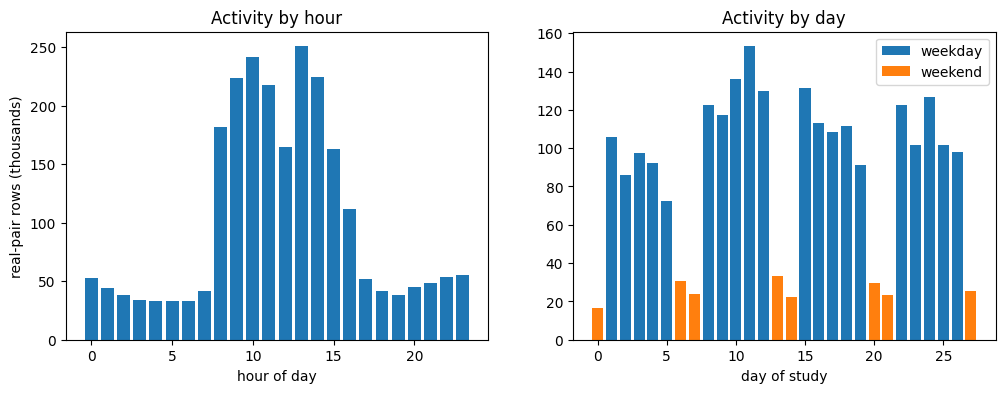

In [17]:
fig = pp.plot_activity(real)

activity increases at 08:00 and goes back down after 16:00, so t=0 is midnight. Days where `day % 7` is 0 or 6 have low activity, indicating they are weekends, and day 0 is a Sunday.

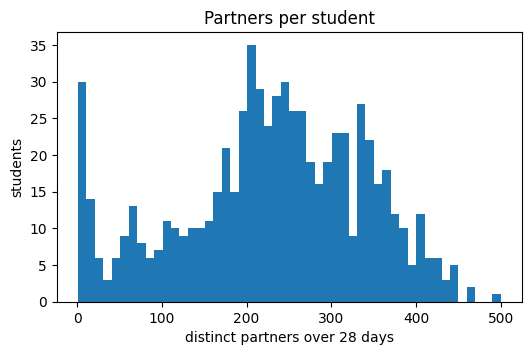

In [20]:
fig = pp.plot_partners(real)

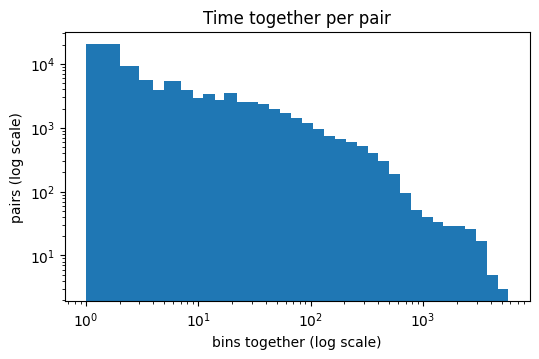

In [21]:
fig = pp.plot_pair_bins(real)

In [31]:
pairs = real[["user_a", "user_b"]].drop_duplicates()
partners = pd.concat([pairs.user_a, pairs.user_b]).value_counts()
n = real.groupby(["user_a", "user_b"]).size()

print("partners per student (25%, 50%, 75%):", partners.quantile([0.25, 0.5, 0.75]).to_list())
print(f"{len(n):,} distinct pairs, {(n == 1).sum():,} ({(n == 1).mean():.0%}) seen in only one bin, median {n.median():.0f} bins")


partners per student (25%, 50%, 75%): [164.5, 236.5, 312.0]
79,530 distinct pairs, 20,580 (26%) seen in only one bin, median 5 bins


Half of the students were near between 165 and 312 others during the four weeks. That is just campus, not necessarily friends.

Of the 79,530 pairs, a quarter appear in one single bin: one five-minute reading in four weeks. Bluetooth reaches through walls, so such a pair may never have met. The median pair has 5 bins, about 25 minutes in total.

Most pairs are noise, as will be shown below.


## Problems in the data

The problems below are about what a row means, not about the format of the file. We will later device what to do with each one.

### 1. RSSI +20

4 readings have RRSI of +20. At these distances dBm is negative, and the stongest real reading is -8, so these four are not "correct".

In [32]:
print("highest real RSSI below zero:", real.rssi[real.rssi < 0].max())
real[real.rssi > 0]

highest real RSSI below zero: -8


,timestamp,user_a,user_b,rssi
540420,263700,286,62,20
1502679,733800,482,42,20
2526438,1097400,268,156,20
4655286,2043000,455,248,20


### 2. Invalid rows

41% of rows are empty scans and 15% are devices outside the study. 

All outside devices share the number -2. These rows say nothing about pairs of students, but they show that a phone was on, which the student table uses.

In [ ]:
print(f"invalid rows: {(bt.user_b < 0).sum():,} ({(bt.user_b < 0).mean():.0%})")

invalid rows: 3,048,010 (56%)


### 3. Counting per student needs both columns.

A pair is stored once, under the larger of the two student numbers. Thus, student 5 owns only 174 of their pair rows, while 12,447 of them sit under the partner. Student 700 owns all 6,150 of theirs.

Bluetooth discovery is also not symmetric: one phone can find another without being found itself. In 282,377 cases another phone sees a student in a bin where that student has no row at all.

So a count taken from one column, or from a student's own rows only, says more about the student number than about the student. Every number we build per student has to use both columns.

In [ ]:
for u in [5, 700]:
    print(f"student {u}: {(real.user_a == u).sum():,} pair rows of their own, {(real.user_b == u).sum():,} under the partner")

# presence() is the union of own rows and being seen, so the difference is what only another phone recorded
own = bt[["timestamp", "user_a"]].drop_duplicates()
print("seen without an own row:", len(pp.presence(bt)) - len(own))

student 5: 174 pair rows of their own, 12,447 under the partner
student 700: 6,150 pair rows of their own, 0 under the partner
seen without an own row: 282377


### 4. Students who never appear in a pair

14 students never appear in a pair, although their phones report. All their rows are empty scans or devices from outside the study.

This looks more like a problem with those phones than fourteen isolated students. They are marked in the student table, so that question B can handle them separately.

In [48]:
never = sorted(set(bt.user_a) - set(real.user_a) - set(real.user_b))
print(len(never), "students never appear in a pair")
bt[bt.user_a.isin(never)].groupby("user_a").size()

14 students never appear in a pair


user_a
9      7630
103    5415
316    2377
398    4096
447     178
511    5121
603    5896
653    1415
670    3701
674     102
679     488
696     186
697     580
712       1
dtype: int64

### 5. Facebook self-friendship

11 rows list a student as their own friend. A friendship needs two people, and these rows would also raise the baseline that we compare our results against.


In [49]:
fb[fb.user_a == fb.user_b]

,user_a,user_b
536,269,269
622,527,527
2209,71,71
2648,341,341
3846,644,644
4405,666,666
5128,187,187
5369,199,199
5507,207,207
5829,476,476


### 6. Students are missing from some layers

The files do not cover the same students. 130 students in the friendship file never appear in the Bluetooth data, and 44 students who call or write messages are missing there too. 35 students with Bluetooth data have no friendships at all.

A student without friendships most likely did not share their Facebook data. Treating that as "no friends" would make friendships look more rare than they are, so comparisons use only the students who appear in both files.

In [ ]:
paired = set(real.user_a) | set(real.user_b) # set union
in_bt = set(bt.user_a) | paired
in_fb = set(fb.user_a) | set(fb.user_b)
in_comm = set(calls.caller) | set(calls.callee) | set(sms.sender) | set(sms.recipient)

print("facebook students never in bluetooth:", len(in_fb - in_bt))
print("call or sms students never in bluetooth:", len(in_comm - in_bt))
print("bluetooth students without facebook friendships:", len(paired - in_fb))

facebook students never in bluetooth: 130
call or sms students never in bluetooth: 44
bluetooth students without facebook friendships: 35


### 7. Duplicate text messages

21 rows appear twice: same sender, same receiver, same second, one copy of each is kept.


In [51]:
sms[sms.duplicated(keep=False)].head(6)

,timestamp,sender,recipient
3294,312440,91,90
3295,312440,91,90
4777,423568,615,507
4778,423568,615,507
5206,476877,176,578
5207,476877,176,578


### 8. Missed and zero-length calls

366 calls have a length of -1, which the README documents as a missed call, and 580 have a length of zero; does a call that nobody answered count as contact?


In [52]:
print("missed calls:", (calls.duration == -1).sum())
print("zero-length calls:", (calls.duration == 0).sum())

missed calls: 366
zero-length calls: 580


## Cleaning

Now we remove rows for the above reasons!